In [1]:
# ================================================================
# BLOQUE 1: IMPORTS GENERALES Y CONFIGURACIÓN
# ================================================================
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
from torchvision import datasets, models, transforms
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import time, copy
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# ================================================================
# BLOQUE 2: RUTAS A DATASETS
# ================================================================

trashnet_dir = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\data_preprocessed\ResNet18\TrashNet"
taco_dir     = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\data_preprocessed\ResNet18\TACO"

output_dir = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\Programas\ResNet\Modelos_experimentos"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ================================================================
# BLOQUE 3: FUNCIONES AUXILIARES
# ================================================================

def split_stratified(dataset, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    
    train_idx, val_idx, test_idx = [], [], []
    for c in classes:
        c_idx = np.where(targets == c)[0]
        np.random.shuffle(c_idx)
        n_total = len(c_idx)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        
        train_idx += list(c_idx[:n_train])
        val_idx   += list(c_idx[n_train:n_train+n_val])
        test_idx  += list(c_idx[n_train+n_val:])
    
    return train_idx, val_idx, test_idx


def make_balanced_sampler(subset, full_dataset):
    targets = np.array(full_dataset.targets)
    subset_targets = targets[subset.indices]
    class_counts = Counter(subset_targets)
    weights = {cls: 1.0/count for cls, count in class_counts.items()}
    sample_weights = [weights[label] for label in subset_targets]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [4]:
# ================================================================
# BLOQUE 4: FUNCIÓN DE ENTRENAMIENTO CON HISTORIAL PARA CURVAS
# ================================================================

def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                num_epochs=20, patience=4, save_name="modelo.pth"):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 50)

        for phase in ["train", "val"]:
            model.train() if phase=="train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase=="train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double()/dataset_sizes[phase]

            print(f"{phase.upper()} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # registrar historial
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            # early stopping
            if phase == "val":
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            print("\nEARLY STOPPING activado")
            break

    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), os.path.join(output_dir, save_name))

    print(f"\nMejor ACC validación: {best_acc:.4f}")
    return model, history

In [5]:
# ================================================================
# BLOQUE 5: FUNCIÓN PARA GRAFICAR CURVAS DE APRENDIZAJE
# ================================================================

def plot_curves(history, title="Curvas de aprendizaje"):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Épocas")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Épocas")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# ================================================================
# FUNCIÓN DE EVALUACIÓN COMPLETA
# Matriz de confusión (gráfica) + metrics por defecto en consola
# ================================================================

def evaluar_en_test(model, loader, class_names, modelo_nombre="Modelo"):
    model.eval()
    all_preds, all_labels = [], []

    # 1. Recolectar predicciones reales vs predichas
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ===========================================================
    # 2. Reporte de clasificación (texto)
    # ===========================================================
    print("\n===============================================")
    print(f"   REPORTES DE EVALUACIÓN - {modelo_nombre}")
    print("===============================================\n")

    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=3
    ))

    # ===========================================================
    # 3. Matriz de confusión (gráfica)
    # ===========================================================

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Matriz de Confusión - {modelo_nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta Real")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)

    # valores dentro de celdas
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # ===========================================================
    # 4. Exactitud total
    # ===========================================================
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Exactitud global en TEST ({modelo_nombre}): {acc:.4f}")

    return acc

Clases TACO: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Época 1/10
--------------------------------------------------
TRAIN | Loss: 1.5092 | Acc: 0.4016
VAL | Loss: 1.2908 | Acc: 0.5360

Época 2/10
--------------------------------------------------
TRAIN | Loss: 1.2012 | Acc: 0.5533
VAL | Loss: 1.2497 | Acc: 0.5360

Época 3/10
--------------------------------------------------
TRAIN | Loss: 1.0786 | Acc: 0.6187
VAL | Loss: 1.3857 | Acc: 0.4533

Época 4/10
--------------------------------------------------
TRAIN | Loss: 1.0363 | Acc: 0.6295
VAL | Loss: 1.2347 | Acc: 0.5636

Época 5/10
--------------------------------------------------
TRAIN | Loss: 1.0079 | Acc: 0.6409
VAL | Loss: 1.1264 | Acc: 0.5835

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.9340 | Acc: 0.6700
VAL | Loss: 1.3078 | Acc: 0.5008

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.9229 | Acc: 0.6723
VAL | Loss: 1.1029 | Acc: 0.5988

Época 8/

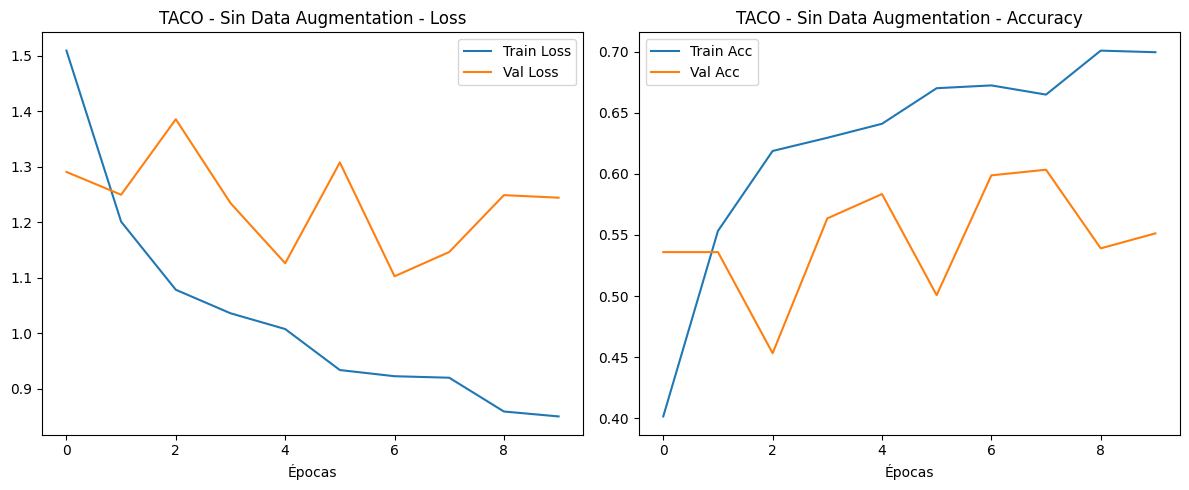

In [7]:
# ================================================================
# BLOQUE 6: ENTRENAMIENTO TRASHNET - SIN DATA AUGMENTATION
# ================================================================

transform = transforms.ToTensor()

# --- AHORA SE CARGA TACO, PERO MANTENEMOS EL NOMBRE trashnet_full ---
trashnet_full = datasets.ImageFolder(taco_dir, transform=transform)
print("Clases TACO:", trashnet_full.classes)

# split estratificado
train_idx, val_idx, test_idx = split_stratified(trashnet_full)
train_ds = Subset(trashnet_full, train_idx)
val_ds   = Subset(trashnet_full, val_idx)
test_ds  = Subset(trashnet_full, test_idx)

sampler  = make_balanced_sampler(train_ds, trashnet_full)

batch = 32
train_loader = DataLoader(train_ds, batch_size=batch, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=batch)
test_loader  = DataLoader(test_ds, batch_size=batch)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

# --- MODELO ---
model_tn = models.resnet18(weights="IMAGENET1K_V1")
for p in model_tn.parameters():
    p.requires_grad = False

# capa final con clases de TACO (aunque el nombre sea trashnet_full)
model_tn.fc = nn.Linear(model_tn.fc.in_features, len(trashnet_full.classes))
model_tn = model_tn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tn.fc.parameters(), lr=1e-3)

model_tn, hist_tn = train_model(
    model_tn, criterion, optimizer,
    dataloaders, dataset_sizes,
    num_epochs=10, patience=4,
    save_name="resnet18_taco_pretrain.pth"
)

plot_curves(hist_tn, "TACO - Sin Data Augmentation")

Clases TACO: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Época 1/10
--------------------------------------------------
TRAIN | Loss: 1.3439 | Acc: 0.5162
VAL | Loss: 1.1143 | Acc: 0.6189

Época 2/10
--------------------------------------------------
TRAIN | Loss: 1.0961 | Acc: 0.6132
VAL | Loss: 1.0399 | Acc: 0.6433

Época 3/10
--------------------------------------------------
TRAIN | Loss: 1.0103 | Acc: 0.6364
VAL | Loss: 0.9804 | Acc: 0.6570

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.9677 | Acc: 0.6615
VAL | Loss: 0.9619 | Acc: 0.6570

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.9363 | Acc: 0.6596
VAL | Loss: 0.9280 | Acc: 0.6768

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.9106 | Acc: 0.6762
VAL | Loss: 0.9324 | Acc: 0.6555

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.9030 | Acc: 0.6762
VAL | Loss: 0.9176 | Acc: 0.6784

Época 8/

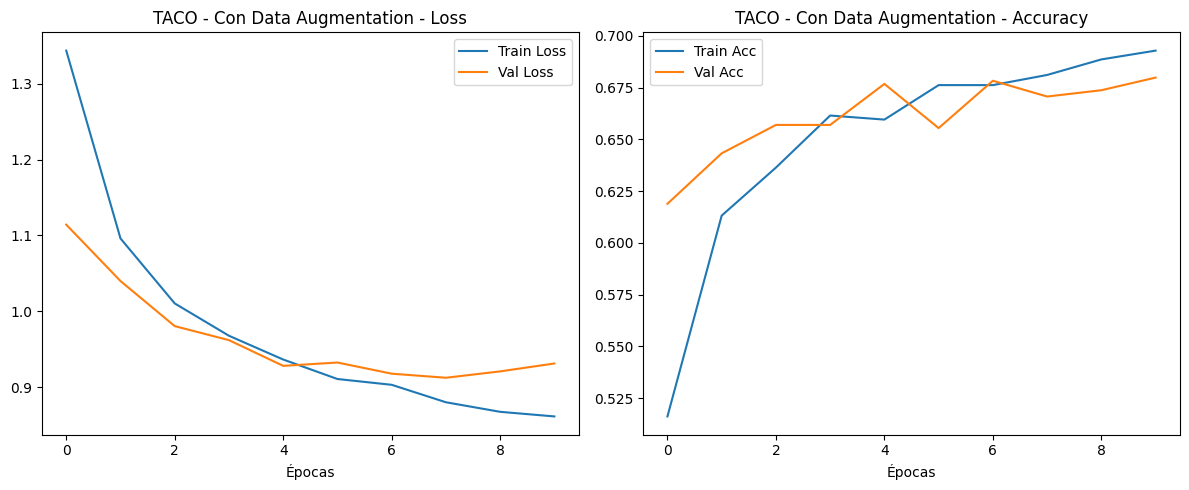

In [8]:
# ================================================================
# BLOQUE 7: ENTRENAMIENTO TRASHNET - CON DATA AUGMENTATION
# ================================================================

train_transform_tn = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

base_transform_tn = transforms.ToTensor()

# --- AHORA ESTE BLOQUE USA TACO EN LUGAR DE TRASHNET ---
trashnet_aug_full = datasets.ImageFolder(taco_dir, transform=train_transform_tn)
print("Clases TACO:", trashnet_aug_full.classes)

# split reproducible
train_size = int(0.7 * len(trashnet_aug_full))
val_size   = int(0.15 * len(trashnet_aug_full))
test_size  = len(trashnet_aug_full) - train_size - val_size

torch.manual_seed(42)
train_ds_aug, val_ds_aug, test_ds_aug = random_split(
    trashnet_aug_full, [train_size, val_size, test_size]
)

# para validación y test: sin augmentación
val_ds_aug.dataset.transform  = base_transform_tn
test_ds_aug.dataset.transform = base_transform_tn

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)
val_loader_aug   = DataLoader(val_ds_aug, batch_size=32)
test_loader_aug  = DataLoader(test_ds_aug, batch_size=32)

dataloaders_aug = {"train": train_loader_aug, "val": val_loader_aug}
dataset_sizes_aug = {"train": len(train_ds_aug), "val": len(val_ds_aug)}

# Modelo
model_tn_aug = models.resnet18(weights="IMAGENET1K_V1")
for p in model_tn_aug.parameters():
    p.requires_grad = False

# número de clases de TACO (aunque el nombre sea trashnet_aug_full)
model_tn_aug.fc = nn.Linear(model_tn_aug.fc.in_features, len(trashnet_aug_full.classes))
model_tn_aug = model_tn_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tn_aug.fc.parameters(), lr=1e-3)

model_tn_aug, hist_tn_aug = train_model(
    model_tn_aug, criterion, optimizer,
    dataloaders_aug, dataset_sizes_aug,
    num_epochs=10, patience=4,
    save_name="resnet18_taco_aug_pretrain.pth"
)

plot_curves(hist_tn_aug, "TACO - Con Data Augmentation")


=== EVALUACIÓN TrashNet - SIN DA ===

   REPORTES DE EVALUACIÓN - TACO_sin_DA → TrashNet

              precision    recall  f1-score   support

   cardboard      0.000     0.000     0.000        36
       glass      0.066     0.579     0.118        38
       metal      0.160     0.241     0.192        79
       paper      0.000     0.000     0.000        34
     plastic      0.372     0.146     0.210       287
       trash      0.071     0.011     0.018       189

    accuracy                          0.128       663
   macro avg      0.111     0.163     0.090       663
weighted avg      0.204     0.128     0.126       663



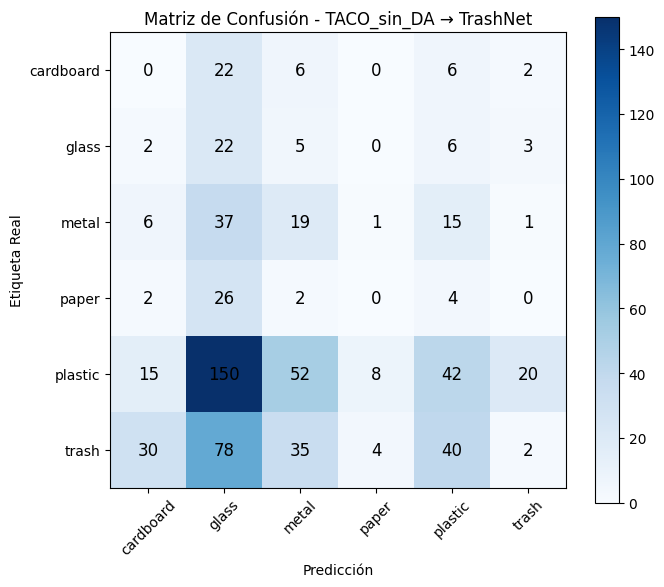

Exactitud global en TEST (TACO_sin_DA → TrashNet): 0.1282

=== EVALUACIÓN TrashNet - CON DA ===

   REPORTES DE EVALUACIÓN - TACO_con_DA → TrashNet

              precision    recall  f1-score   support

   cardboard      0.500     0.030     0.057        33
       glass      0.067     0.025     0.036        40
       metal      0.000     0.000     0.000        71
       paper      0.033     0.864     0.064        22
     plastic      0.000     0.000     0.000       306
       trash      0.226     0.076     0.113       185

    accuracy                          0.053       657
   macro avg      0.138     0.166     0.045       657
weighted avg      0.094     0.053     0.039       657



d:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


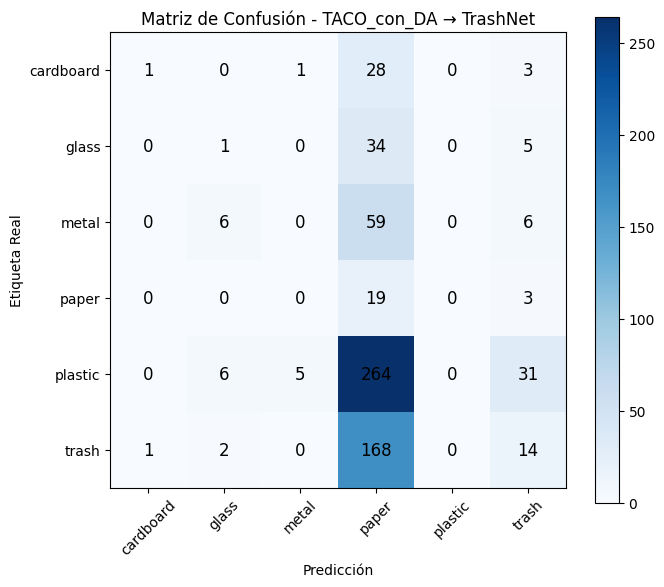

Exactitud global en TEST (TACO_con_DA → TrashNet): 0.0533

>> Exactitud TrashNet Sin DA: 0.1282051282051282
>> Exactitud TrashNet Con DA: 0.0532724505327245


In [9]:
# ================================================================
# BLOQUE 8: EVALUACIÓN TRASHNET (CON MATRICES DE CONFUSIÓN)
#   (Ahora evaluando modelos entrenados en TACO sobre TrashNet)
# ================================================================

print("\n=== EVALUACIÓN TrashNet - SIN DA ===")

# ------------------------------------------------------------
# Reconstruir modelo_tn para cargar pesos entrenados en TACO
# ------------------------------------------------------------
model_tn = models.resnet18(weights="IMAGENET1K_V1")

# capa temporal para cargar pesos TACO sin DA
model_tn.fc = nn.Linear(model_tn.fc.in_features, len(trashnet_full.classes))

# cargar pesos entrenados en TACO (sin DA)
model_tn.load_state_dict(torch.load(os.path.join(output_dir, "resnet18_taco_pretrain.pth")))

# reemplazar FC por clases reales de TrashNet
model_tn.fc = nn.Linear(model_tn.fc.in_features, len(trashnet_full.classes))
model_tn = model_tn.to(device)

acc_tn = evaluar_en_test(
    model_tn,
    test_loader,                   # test de TrashNet
    trashnet_full.classes,
    modelo_nombre="TACO_sin_DA → TrashNet"
)


print("\n=== EVALUACIÓN TrashNet - CON DA ===")

# ------------------------------------------------------------
# Reconstruir modelo_tn_aug para cargar pesos TACO con DA
# ------------------------------------------------------------
model_tn_aug = models.resnet18(weights="IMAGENET1K_V1")

# capa temporal según TACO con DA
model_tn_aug.fc = nn.Linear(model_tn_aug.fc.in_features, len(trashnet_aug_full.classes))

# cargar pesos TACO con DA
model_tn_aug.load_state_dict(torch.load(os.path.join(output_dir, "resnet18_taco_aug_pretrain.pth")))

# sustituir FC por clases de TrashNet
model_tn_aug.fc = nn.Linear(model_tn_aug.fc.in_features, len(trashnet_full.classes))
model_tn_aug = model_tn_aug.to(device)

acc_tn_aug = evaluar_en_test(
    model_tn_aug,
    test_loader_aug,               # también test de TrashNet (misma estructura respetada)
    trashnet_full.classes,
    modelo_nombre="TACO_con_DA → TrashNet"
)


print("\n>> Exactitud TrashNet Sin DA:", acc_tn)
print(">> Exactitud TrashNet Con DA:", acc_tn_aug)


In [10]:
# ================================================================
# BLOQUE 9: TRANSFER LEARNING TACO → TRASHNET
# ================================================================

print("\nCargando pesos del modelo preentrenado en TACO (con DA)...")

# 1. Cargar modelo base ResNet18
model_trashnet_transfer = models.resnet18(weights="IMAGENET1K_V1")

# 2. Reemplazar capa final TEMPORALMENTE con las clases de TACO
#    (debe coincidir con la FC usada al entrenar el checkpoint)
taco_classes_source = datasets.ImageFolder(taco_dir)
num_classes_taco = len(taco_classes_source.classes)
model_trashnet_transfer.fc = nn.Linear(
    model_trashnet_transfer.fc.in_features,
    num_classes_taco
)

# 3. Cargar pesos entrenados en TACO (CON DA)
checkpoint_path = os.path.join(output_dir, "resnet18_taco_aug_pretrain.pth")
model_trashnet_transfer.load_state_dict(torch.load(checkpoint_path))

# 4. Ahora reemplazar la FC REAL con el número correcto de clases de TRASHNET
trashnet_classes_target = datasets.ImageFolder(trashnet_dir)
num_classes_trash = len(trashnet_classes_target.classes)
model_trashnet_transfer.fc = nn.Linear(
    model_trashnet_transfer.fc.in_features,
    num_classes_trash
)

model_trashnet_transfer = model_trashnet_transfer.to(device)

print("Clases TrashNet:", trashnet_classes_target.classes)


Cargando pesos del modelo preentrenado en TACO (con DA)...
Clases TrashNet: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']



Época 1/10
--------------------------------------------------
TRAIN | Loss: 0.6556 | Acc: 0.7862
VAL | Loss: 0.4769 | Acc: 0.8365

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.1619 | Acc: 0.9564
VAL | Loss: 0.3472 | Acc: 0.8954

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.0967 | Acc: 0.9754
VAL | Loss: 0.2794 | Acc: 0.9196

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.0402 | Acc: 0.9914
VAL | Loss: 0.3145 | Acc: 0.9035

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.0167 | Acc: 0.9989
VAL | Loss: 0.2925 | Acc: 0.9223

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.0221 | Acc: 0.9966
VAL | Loss: 0.3096 | Acc: 0.9062

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.0133 | Acc: 0.9983
VAL | Loss: 0.2716 | Acc: 0.9249

Época 8/10
--------------------------------------------------
TRAIN | Loss: 0.0085

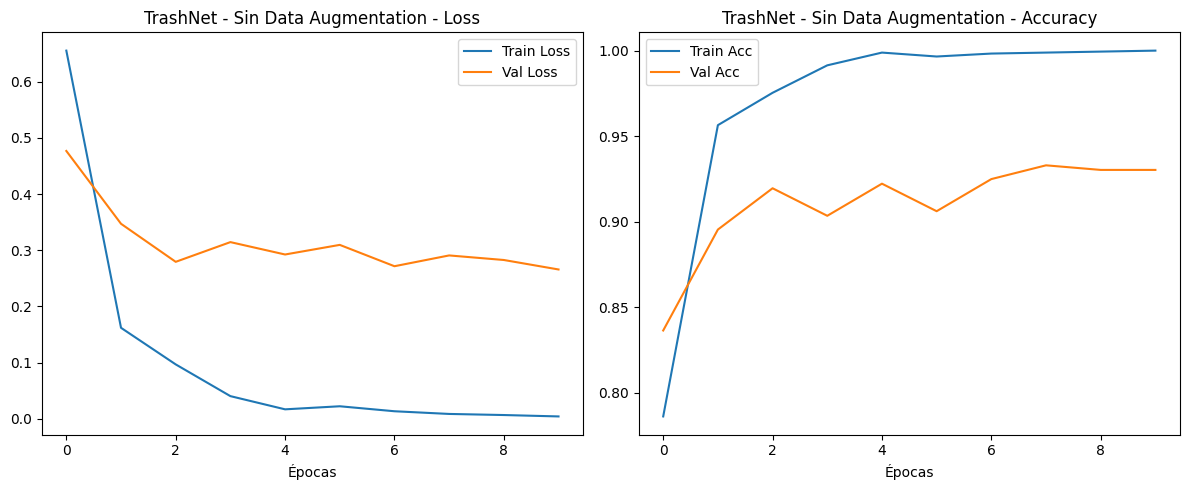

In [12]:
# ================================================================
# BLOQUE 10.1: TRASHNET - SIN DATA AUGMENTATION
# ================================================================

no_transform = transforms.ToTensor()
trashnet_full = datasets.ImageFolder(trashnet_dir, transform=no_transform)

train_idx, val_idx, test_idx = split_stratified(trashnet_full)
train_ds_trash = Subset(trashnet_full, train_idx)
val_ds_trash   = Subset(trashnet_full, val_idx)
test_ds_trash  = Subset(trashnet_full, test_idx)

sampler_trash = make_balanced_sampler(train_ds_trash, trashnet_full)

train_loader_trash = DataLoader(train_ds_trash, batch_size=32, sampler=sampler_trash)
val_loader_trash   = DataLoader(val_ds_trash, batch_size=32)
test_loader_trash  = DataLoader(test_ds_trash, batch_size=32)

dataloaders_trash = {"train": train_loader_trash, "val": val_loader_trash}
dataset_sizes_trash = {"train": len(train_ds_trash), "val": len(val_ds_trash)}

criterion = nn.CrossEntropyLoss()

# 🇨🇴 CORRECCIÓN IMPORTANTE:
# model_taco YA NO EXISTE —> AHORA ES model_trashnet_transfer
optimizer = optim.Adam(model_trashnet_transfer.parameters(), lr=1e-4)

model_trashnet_sinDA, hist_trashnet_sinDA = train_model(
    model_trashnet_transfer, criterion, optimizer,
    dataloaders_trash, dataset_sizes_trash,
    num_epochs=10, patience=4,
    save_name="resnet18_taco_to_trashnet_sinDA.pth"
)

plot_curves(hist_trashnet_sinDA, "TrashNet - Sin Data Augmentation")


Época 1/10
--------------------------------------------------
TRAIN | Loss: 0.7658 | Acc: 0.7284
VAL | Loss: 0.4173 | Acc: 0.8422

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.1619 | Acc: 0.9617
VAL | Loss: 0.3209 | Acc: 0.8957

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.0433 | Acc: 0.9971
VAL | Loss: 0.2605 | Acc: 0.9064

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.0218 | Acc: 0.9994
VAL | Loss: 0.2664 | Acc: 0.9225

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.0095 | Acc: 1.0000
VAL | Loss: 0.2497 | Acc: 0.9091

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.0056 | Acc: 1.0000
VAL | Loss: 0.2372 | Acc: 0.9225

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.0049 | Acc: 1.0000
VAL | Loss: 0.2519 | Acc: 0.9198

Época 8/10
--------------------------------------------------
TRAIN | Loss: 0.0037

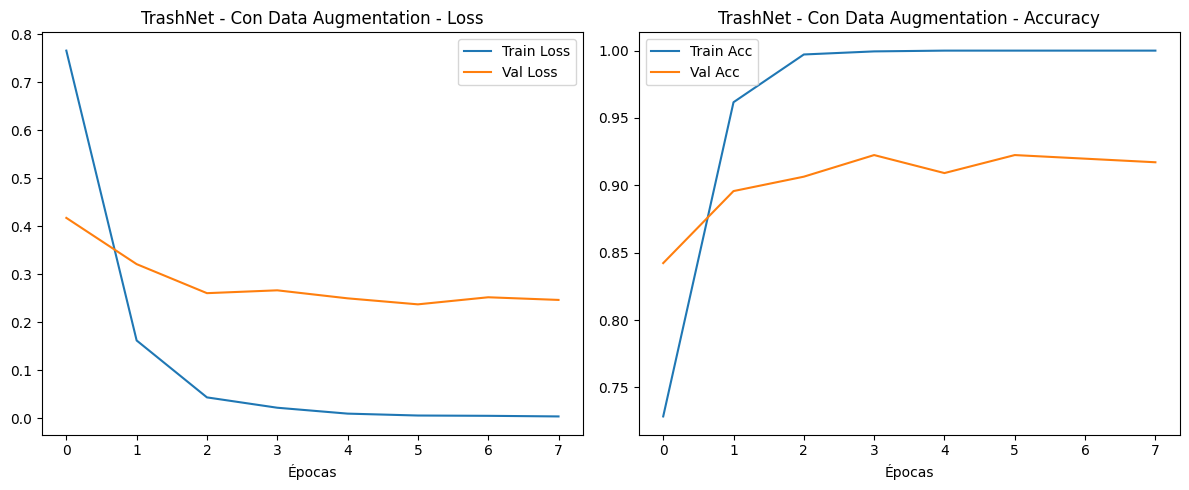

In [13]:
# ================================================================
# BLOQUE 10.2: TRASHNET - CON DATA AUGMENTATION
# ================================================================

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

base_transform = transforms.ToTensor()

trashnet_full_aug = datasets.ImageFolder(trashnet_dir, transform=train_transform)

train_size = int(0.7 * len(trashnet_full_aug))
val_size   = int(0.15 * len(trashnet_full_aug))
test_size  = len(trashnet_full_aug) - train_size - val_size

torch.manual_seed(42)
train_ds_trash_aug, val_ds_trash_aug, test_ds_trash_aug = random_split(
    trashnet_full_aug, [train_size, val_size, test_size]
)

val_ds_trash_aug.dataset.transform  = base_transform
test_ds_trash_aug.dataset.transform = base_transform

train_loader_trash_aug = DataLoader(train_ds_trash_aug, batch_size=32, shuffle=True)
val_loader_trash_aug   = DataLoader(val_ds_trash_aug, batch_size=32)
test_loader_trash_aug  = DataLoader(test_ds_trash_aug, batch_size=32)

dataloaders_trash_aug = {"train": train_loader_trash_aug, "val": val_loader_trash_aug}
dataset_sizes_trash_aug = {"train": len(train_ds_trash_aug), "val": len(val_ds_trash_aug)}

# 1. Crear modelo base con pesos entrenados en TACO (con DA)
model_taco_aug = models.resnet18(weights="IMAGENET1K_V1")
model_taco_aug.fc = nn.Linear(model_taco_aug.fc.in_features, num_classes_taco)

# cargar pesos TACO (con DA)
checkpoint_path = os.path.join(output_dir, "resnet18_taco_aug_pretrain.pth")
model_taco_aug.load_state_dict(torch.load(checkpoint_path))

# 2. Reemplazar FC por clases reales de TrashNet (6 clases)
trash_temp = datasets.ImageFolder(trashnet_dir)
num_classes_trash = len(trash_temp.classes)
model_taco_aug.fc = nn.Linear(model_taco_aug.fc.in_features, num_classes_trash)
model_taco_aug = model_taco_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_taco_aug.parameters(), lr=1e-4)

model_trashnet_conDA, hist_trashnet_conDA = train_model(
    model_taco_aug, criterion, optimizer,
    dataloaders_trash_aug, dataset_sizes_trash_aug,
    num_epochs=10, patience=4,
    save_name="resnet18_taco_to_trashnet_conDA.pth"
)

plot_curves(hist_trashnet_conDA, "TrashNet - Con Data Augmentation")


=== TrashNet - SIN DA ===

   REPORTES DE EVALUACIÓN - TACO→TrashNet - Sin DA

              precision    recall  f1-score   support

   cardboard      0.965     0.902     0.932        61
       glass      0.932     0.895     0.913        76
       metal      0.868     0.952     0.908        62
       paper      0.933     0.966     0.949        87
     plastic      0.897     0.836     0.865        73
       trash      0.840     0.955     0.894        22

    accuracy                          0.913       381
   macro avg      0.906     0.917     0.910       381
weighted avg      0.915     0.913     0.913       381



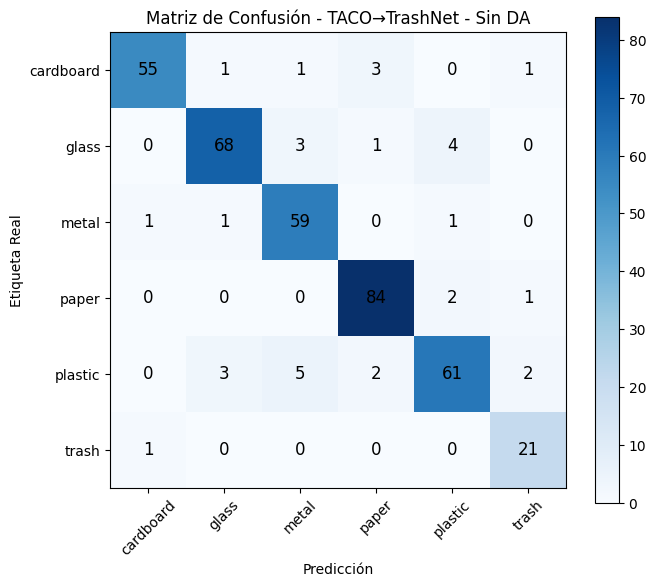

Exactitud global en TEST (TACO→TrashNet - Sin DA): 0.9134

=== TrashNet - CON DA ===

   REPORTES DE EVALUACIÓN - TACO→TrashNet - Con DA

              precision    recall  f1-score   support

   cardboard      0.964     0.931     0.947        58
       glass      0.929     0.878     0.903        90
       metal      0.800     0.906     0.850        53
       paper      0.918     0.963     0.940        81
     plastic      0.930     0.904     0.917        73
       trash      0.895     0.810     0.850        21

    accuracy                          0.910       376
   macro avg      0.906     0.899     0.901       376
weighted avg      0.912     0.910     0.910       376



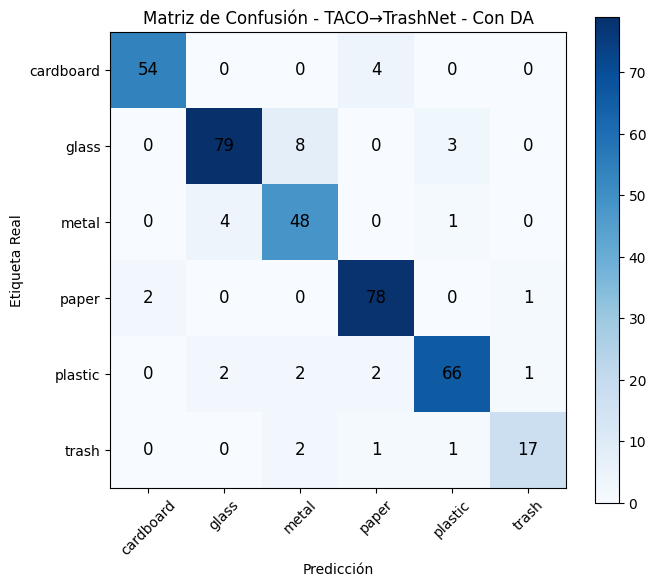

Exactitud global en TEST (TACO→TrashNet - Con DA): 0.9096

>> Exactitud TrashNet Sin DA: 0.9133858267716536
>> Exactitud TrashNet Con DA: 0.9095744680851063


In [14]:
# ================================================================
# BLOQUE 11: EVALUACIÓN FINAL TRASHNET (CON MATRICES DE CONFUSIÓN)
# ================================================================

print("\n=== TrashNet - SIN DA ===")
acc_trashnet_sinDA = evaluar_en_test(
    model_trashnet_sinDA,
    test_loader_trash,
    trashnet_full.classes,
    modelo_nombre="TACO→TrashNet - Sin DA"
)

print("\n=== TrashNet - CON DA ===")
acc_trashnet_conDA = evaluar_en_test(
    model_trashnet_conDA,
    test_loader_trash_aug,
    trashnet_full_aug.classes,
    modelo_nombre="TACO→TrashNet - Con DA"
)

print("\n>> Exactitud TrashNet Sin DA:", acc_trashnet_sinDA)
print(">> Exactitud TrashNet Con DA:", acc_trashnet_conDA)
